<a href="https://colab.research.google.com/github/jamalamro25/CMP7005_PRAC1_Jamalamro/blob/main/Final_Assignment_CMP7005_PRAC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Introduction**

## Dataset Background and Objective

The Indian Cities Air Quality Dataset, compiled from multiple city files, contains daily measurements of key atmospheric pollutants such as PM2.5, PM10, NO₂, NOx, SO₂, CO, O₃, NH₃, Benzene, Toluene, and Xylene. Along with pollutant levels, the dataset also includes date and city information, enabling a detailed analysis of air pollution patterns across different regions of India.

The primary objective of this project is to clean, integrate, and analyse this multi-city dataset to understand pollution trends, compare air quality between cities, and identify the factors contributing to high AQI (Air Quality Index) readings. Python-based data processing, exploratory data analysis (EDA) are used, and predictive modelling to uncover insights that support environmental planning and policy decisions.

## Main Reason for Conducting the Project

The main purpose of this project is to apply professional data analysis and visualization techniques to a real-world environmental dataset. By transforming raw air-quality readings into meaningful insights, the project demonstrates practical skills in:


*  Data cleaning & preprocessing

*  Exploratory data analysis (EDA)

*  Machine learning modelling

*  Streamlit dashboard (Application Development)

More importantly, the work provides a deeper understanding of pollution patterns across Indian cities, helping highlight areas with critical air-quality challenges and trends that require attention.



## **2. Data Handling**

**2.1 Import Necessary libraries**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from   plotly.subplots import make_subplots
import os

**2.2 Load Dataset**

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
%cd '/content/drive/MyDrive/Programming for Data Analysis/Assigment/Assessment Data-20251028'

/content/drive/MyDrive/Programming for Data Analysis/Assigment/Assessment Data-20251028


In [58]:
%ls

Ahmedabad_data.csv     Coimbatore_data.csv  Kolkata_data.csv
Aizawl_data.csv        Delhi_data.csv       Lucknow_data.csv
Amaravati_data.csv     Ernakulam_data.csv   Mumbai_data.csv
Amritsar_data.csv      Gurugram_data.csv    Patna_data.csv
Bengaluru_data.csv     Guwahati_data.csv    Shillong_data.csv
Bhopal_data.csv        Hyderabad_data.csv   Talcher_data.csv
Brajrajnagar_data.csv  Jaipur_data.csv      Thiruvananthapuram_data.csv
Chandigarh_data.csv    Jorapokhar_data.csv  Visakhapatnam_data.csv
Chennai_data.csv       Kochi_data.csv


In [59]:
drive_path = '/content/drive/MyDrive/Programming for Data Analysis/Assigment/Assessment Data-20251028'

In [60]:
dataframes = []
for filename in os.listdir(drive_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(drive_path, filename)
        df_temp = pd.read_csv(os.path.join(drive_path, filename))
        dataframes.append(df_temp)


In [61]:
df = pd.concat(dataframes, ignore_index=True)

In [62]:
print("Merged data shape:", df.shape)

Merged data shape: (29531, 16)


At this point, I began by importing the essential Python libraries required for handling, analysing, and visualising the dataset. After preparing the environment, I mounted Google Drive to securely access the folder containing all city-level CSV files. Each file was then loaded and combined into a single unified dataset, ensuring that all air-quality records were brought together in one place for consistent analysis. Once merged, I checked the overall shape of the dataset to understand its size and structure, confirming the number of rows, columns, and the completeness of the imported data before moving into deeper exploration.

**2.2 Initial Inspection**

In [63]:
df.shape

(29531, 16)

In [64]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [65]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Brajrajnagar,07/12/2017,171.38,311.68,NaN,41.07,NaN,7.78,3.26,5.83,4.69,0.0,NaN,NaN,NaN,NaN
1,Brajrajnagar,08/12/2017,126.67,192.81,NaN,20.16,NaN,7.97,2.94,5.43,10.51,0.0,NaN,NaN,304.0,Very Poor
2,Brajrajnagar,09/12/2017,105.11,154.39,NaN,18.40,NaN,8.15,2.83,5.10,10.33,0.0,NaN,NaN,291.0,Poor
3,Brajrajnagar,10/12/2017,65.25,99.73,NaN,15.21,NaN,7.90,2.74,4.75,8.37,0.0,NaN,NaN,189.0,Moderate
4,Brajrajnagar,11/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Patna,27/06/2020,17.71,63.73,9.47,23.01,22.28,1.91,0.87,3.63,23.39,1.09,3.07,0.97,65.0,Satisfactory
29527,Patna,28/06/2020,19.27,57.42,30.19,18.13,36.76,2.05,0.72,3.92,17.37,1.18,2.90,1.24,82.0,Satisfactory
29528,Patna,29/06/2020,17.24,42.83,42.40,20.51,47.69,2.26,0.88,3.60,17.50,1.51,4.91,1.74,88.0,Satisfactory
29529,Patna,30/06/2020,29.76,60.68,42.12,27.50,52.04,1.59,0.83,3.91,21.70,1.58,8.59,2.02,93.0,Satisfactory
29530,Patna,01/07/2020,35.42,57.82,44.50,31.15,57.72,1.14,0.82,3.99,25.76,1.73,5.50,2.14,98.0,Satisfactory


In [67]:
df.dtypes

,0
City,object
Date,object
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64


In [68]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [70]:
df.isnull().sum().sort_values(ascending=False)

,0
Xylene,18109
PM10,11140
NH3,10328
Toluene,8041
Benzene,5623
AQI,4681
AQI_Bucket,4681
PM2.5,4598
NOx,4185
O3,4022


In [71]:
df.duplicated().sum()

np.int64(0)

**Inferences**

The initial understanding shows that the merged dataset contains 29,531 records across 16 variables, covering multiple cities, dates, and major air-quality pollutants. All numeric pollutant columns were successfully interpreted as continuous variables, while City and AQI_Bucket were correctly identified as categorical attributes. No duplicate records were detected, confirming that the dataset structure is consistent and suitable for further analysis.

However, the inspection also revealed substantial missing values in several pollutant measurements, particularly for Xylene, PM10, NH3, and selected nitrogen compounds, while the City and Date fields contain no missing entries. This pattern suggests differences in pollutant monitoring availability across locations and time periods rather than data corruption. These findings justify the use of targeted and pollutant-specific missing-value handling strategies in the subsequent data-cleaning and feature-engineering stages.

**2.4 Data Cleaning Steps**

In [72]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
print(" Extra spaces removed from the all columns")

 Extra spaces removed from the all columns


In [73]:
def missing_value_table(df):
        mis_val = df.isnull().sum()
        mis_val_per = 100 * df.isnull().sum() / len(df)
        mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
        mis_val_table = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        mis_val_table = mis_val_table[mis_val_table.iloc[:,1] != 0].sort_values('% of Total Values', ascending=False)
        return mis_val_table
missing_values = missing_value_table(df)
display(missing_values.style.background_gradient(cmap='Reds'))



,Missing Values,% of Total Values
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


In [74]:
df['Date']= pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
print("Invalid dates :", df['Date'].isnull().sum())

df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)
print(df['Date'].head(10))
print(df.dtypes['Date'])

Invalid dates : 0
0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
5   2015-01-06
6   2015-01-07
7   2015-01-08
8   2015-01-09
9   2015-01-10
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [75]:
df['City'].value_counts().head(20)

,count
City,
Ahmedabad,2009
Bengaluru,2009
Chennai,2009
Mumbai,2009
Lucknow,2009
Delhi,2009
Hyderabad,2006
Patna,1858
Gurugram,1679


In [76]:
df.isnull().sum().sort_values(ascending=False)

,0
Xylene,18109
PM10,11140
NH3,10328
Toluene,8041
Benzene,5623
AQI,4681
AQI_Bucket,4681
PM2.5,4598
NOx,4185
O3,4022


**2.5 Handling Missing Values**

In [77]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# =================================================================
# 1. Initial Cleaning and Type Conversion
# =================================================================

# Replace obvious text-based missing placeholders
df.replace(["", " ", "-", "--", "NA", "N/A", "na", "null", "None"], np.nan, inplace=True)

# Convert potentially numeric columns to numeric (force errors to NaN)
for col in df.columns:
    # We explicitly exclude 'City' and 'AQI_Bucket' which are meant to be categorical
    if df[col].dtype == 'object' and col not in ['City', 'AQI_Bucket', 'Date']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Step 1: Initial cleanup and type conversion complete.")
print("-" * 50)

# =================================================================
# 2. Imputation Logic (Based on Original and Necessary Additions)
# =================================================================

# Define columns that have special handling rules
special_numeric_cols = {"Xylene", "AQI", "PM10", "Toluene", "Benzene", "NH3"}

# --- Rule 1: PM10, Toluene, Benzene → fill with median ---
for col in ["PM10", "Toluene", "Benzene"]:
    if col in df.columns and df[col].isna().any():
        med_val = df[col].median(skipna=True)
        df[col].fillna(med_val, inplace=True)
        print(f" {col} filled with median ({round(med_val, 2)}).")

# --- Rule 2: NH3 → fill using per-city regression (fallback to median) ---
if "NH3" in df.columns and "City" in df.columns and df["NH3"].isna().any():
    before = df["NH3"].isna().sum()
    # Use all other relevant numeric columns as predictors, excluding the target and skipped ones
    predictors = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ["NH3", "Xylene", "AQI"]]

    # 2a. Regression Imputation
    for city, grp in df.groupby("City"):
        train = grp.dropna(subset=["NH3"] + predictors)
        test = grp[grp["NH3"].isna() & grp[predictors].notna().all(axis=1)]
        if len(train) >= 10 and len(test) > 0:
            model = LinearRegression()
            model.fit(train[predictors], train["NH3"])
            df.loc[test.index, "NH3"] = model.predict(test[predictors])

    # 2b. Fallback Imputation (City Median, then Global Median)
    df["NH3"] = df.groupby("City")["NH3"].transform(lambda x: x.fillna(x.median()))
    df["NH3"].fillna(df["NH3"].median(), inplace=True)
    after = df["NH3"].isna().sum()
    print(f" NH3 regression filled {before - after} values.")

# --- Rule 3: All other *numeric* columns (e.g., SO2, CO, NOX) → fill with mean ---
for col in df.select_dtypes(include=[np.number]).columns:
    if col not in special_numeric_cols and df[col].isna().any():
        mean_val = df[col].mean(skipna=True)
        df[col].fillna(mean_val, inplace=True)
        print(f" {col} filled with mean ({round(mean_val, 2)}).")

# --- Rule 4: Handle previously skipped 'Xylene' and 'AQI' (using mean) ---
for col in ["Xylene", "AQI"]:
    if col in df.columns and df[col].isna().any():
        mean_val = df[col].mean(skipna=True)
        df[col].fillna(mean_val, inplace=True)
        print(f" {col} filled with mean ({round(mean_val, 2)}).")

print("-" * 50)
print("Step 2: Numeric imputation complete.")
print("-" * 50)

# =================================================================
# 3. Impute Categorical/Date Columns (The columns still missing)
# =================================================================

# --- Rule 5: Impute Categorical/Date with the Mode (Most Frequent) ---
categorical_cols = ["City", "AQI_Bucket", "Date", "Year", "Month"]

for col in categorical_cols:
    if col in df.columns and df[col].isna().any():
        # Mode is the most appropriate for categorical data
        mode_val = df[col].mode()
        if not mode_val.empty:
            mode_val = mode_val[0] # Get the first mode if multiple exist
            df[col].fillna(mode_val, inplace=True)
            print(f" {col} filled with mode ({mode_val}).")
        else:
            print(f" {col} is entirely NaN, cannot fill with mode.")

# --- Round continuous numeric columns to 2 decimals only ---
round_cols = ["PM2.5", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3"]

for col in round_cols:
    if col in df.columns:
        df[col] = df[col].round(2)

# --- Convert AQI to integer only ---
if "AQI" in df.columns:
    df["AQI"] = df["AQI"].round(0).astype(int)


# =================================================================
# 4. Final Verification
# =================================================================

print("\nMissing value imputation completed successfully.")
# Display the final summary to confirm all values are zero
print("\nFinal missing value check:")


print(df.isnull().sum().sort_values(ascending=False).head(10))





Step 1: Initial cleanup and type conversion complete.
--------------------------------------------------
 PM10 filled with median (95.68).
 Toluene filled with median (2.97).
 Benzene filled with median (1.07).
 NH3 regression filled 10328 values.
 PM2.5 filled with mean (67.45).
 NO filled with mean (17.57).
 NO2 filled with mean (28.56).
 NOx filled with mean (32.31).
 CO filled with mean (2.25).
 SO2 filled with mean (14.53).
 O3 filled with mean (34.49).
 Xylene filled with mean (3.07).
 AQI filled with mean (166.46).
--------------------------------------------------
Step 2: Numeric imputation complete.
--------------------------------------------------
 AQI_Bucket filled with mode (Moderate).

Missing value imputation completed successfully.

Final missing value check:
City     0
Date     0
PM2.5    0
PM10     0
NO       0
NO2      0
NOx      0
NH3      0
CO       0
SO2      0
dtype: int64


**2.5 Feature Engineering**

In [78]:
# Add year, month and day columns
df['Year']= df['Date'].dt.year
df['Month']= df['Date'].dt.month
df['Day']= df['Date'].dt.day

# Add Region Column (India Cities)
df['City'] = df['City'].astype(str).str.strip()
region_map = {

    # West India
    'Ahmedabad': 'West',
    'Mumbai': 'West',

    # South India
    'Bengaluru': 'South',
    'Chennai': 'South',
    'Coimbatore': 'South',
    'Ernakulam': 'South',
    'Kochi': 'South',
    'Hyderabad': 'South',
    'Thiruvananthapuram': 'South',
    'Visakhapatnam': 'South',
    'Amaravati': 'South',

    # North India
    'Delhi': 'North',
    'Gurugram': 'North',
    'Amritsar': 'North',
    'Chandigarh': 'North',
    'Jaipur': 'North',
    'Lucknow': 'North',

    # East India
    'Kolkata': 'East',
    'Patna': 'East',
    'Brajrajnagar': 'East',
    'Talcher': 'East',
    'Aizawl': 'East',
    'Jorapokhar': 'East',

    # Central India
    'Bhopal': 'Central',

    # North-East India
    'Guwahati': 'Northeast',
    'Shillong': 'Northeast'
}

# Apply Region mapping
df['City'] = df['City'].astype(str).str.strip()
# apply the mapping
df['Region'] = df['City'].map(region_map).fillna('Other')


# Check
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,Region
0,Ahmedabad,2015-01-01,67.45,95.68,0.92,18.22,17.15,14.75,0.92,27.64,133.36,0.00,0.02,0.00,166,Moderate,2015,1,1,West
1,Ahmedabad,2015-01-02,67.45,95.68,0.97,15.69,16.46,14.75,0.97,24.55,34.06,3.68,5.50,3.77,166,Moderate,2015,1,2,West
2,Ahmedabad,2015-01-03,67.45,95.68,17.40,19.30,29.70,14.75,17.40,29.07,30.70,6.80,16.40,2.25,166,Moderate,2015,1,3,West
3,Ahmedabad,2015-01-04,67.45,95.68,1.70,18.48,17.97,14.75,1.70,18.59,36.08,4.43,10.14,1.00,166,Moderate,2015,1,4,West
4,Ahmedabad,2015-01-05,67.45,95.68,22.10,21.42,37.76,14.75,22.10,39.33,39.31,7.01,18.89,2.78,166,Moderate,2015,1,5,West


#Inferences:

(1) Missing-value handling strategy
A combination of mean, median, mode, and regression-based imputation was applied to address missing values while preserving the statistical integrity of the dataset. Median imputation was selected for pollutants such as PM10, Benzene, and Toluene due to their skewed distributions and sensitivity to outliers, whereas mean imputation was used for more stable pollutants where values fluctuate smoothly over time. Mode imputation was applied to categorical variables to retain the most representative class. For NH3, a per-city linear regression approach was employed to infer missing values using relationships with other pollutants, with city-level and global medians used as fallbacks. This approach aligns with best practices in data preprocessing, where imputation methods are chosen based on data distribution and variable behaviour (Sial, Rashdi & Khan, 2021).

(2) Feature engineering rationale
Feature engineering was conducted to enhance both exploratory analysis and predictive modelling. Temporal features (Year, Month, Day) were extracted from the Date column to support seasonal and trend-based analysis, while a new Region feature was engineered by mapping cities to their geographical zones within India. These transformations improved interpretability, enabled regional comparisons, and provided structured inputs for downstream machine-learning tasks. Overall, the engineered features added meaningful contextual information without introducing data leakage, thereby strengthening the analytical and modelling stages of the project.

## **3. Exploratory Data Analysis (EDA)**

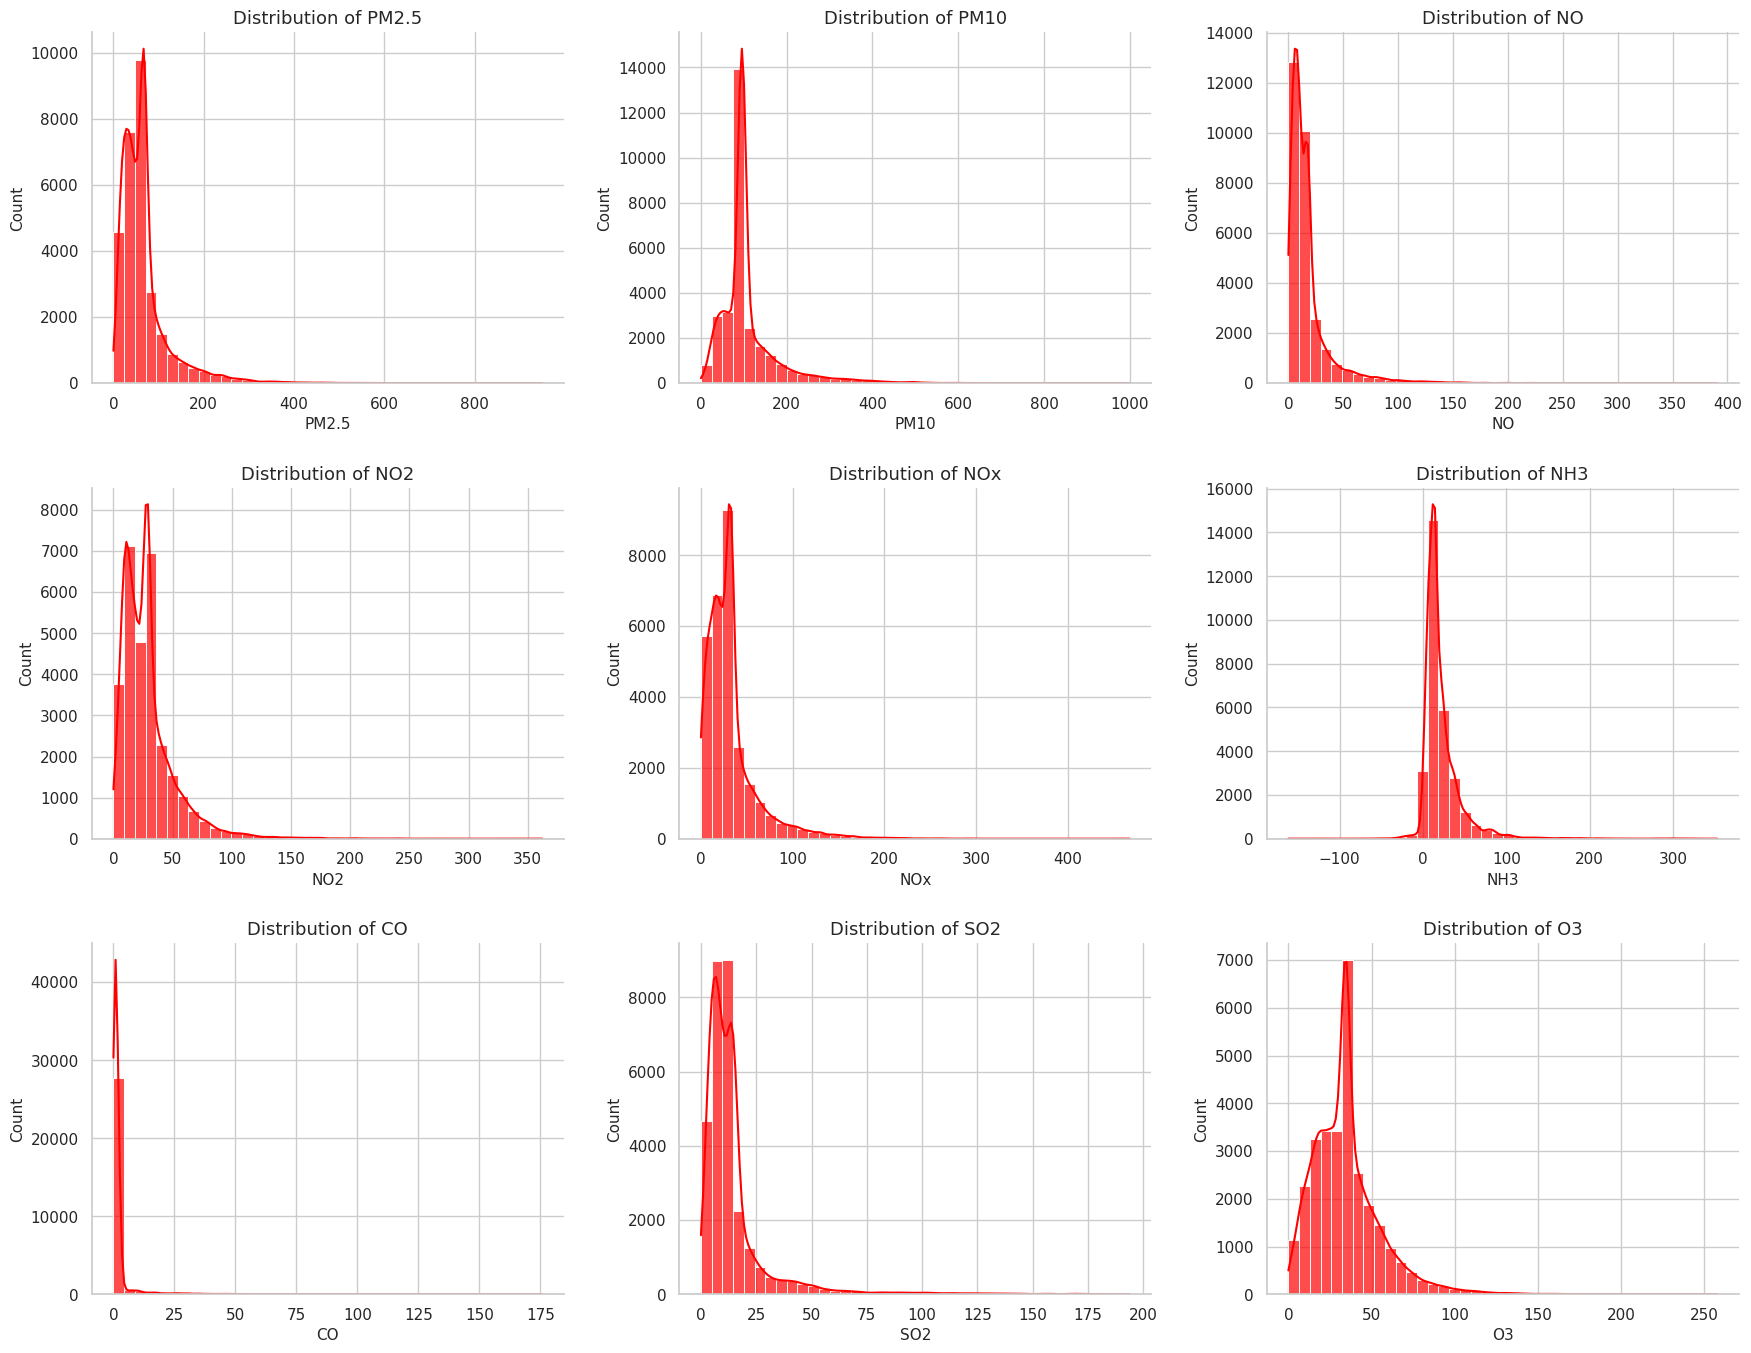

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pollutants = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3"]

plt.figure(figsize=(18,14))

for i, col in enumerate(pollutants, 1):
    plt.subplot(3,3,i)

    sns.histplot(
        df[col],
        bins=40,          # fewer bins → clearer
        kde=True,         # smooth KDE curve
        color="Red",
        alpha=0.7,        # transparency for clarity
        edgecolor=None
    )

    plt.title(f"Distribution of {col}", fontsize=13)
    plt.xlabel(col, fontsize=11)
    plt.ylabel("Count", fontsize=11)

    # Cleaning up visual noise
    sns.despine()

plt.tight_layout(pad=2)
plt.show()



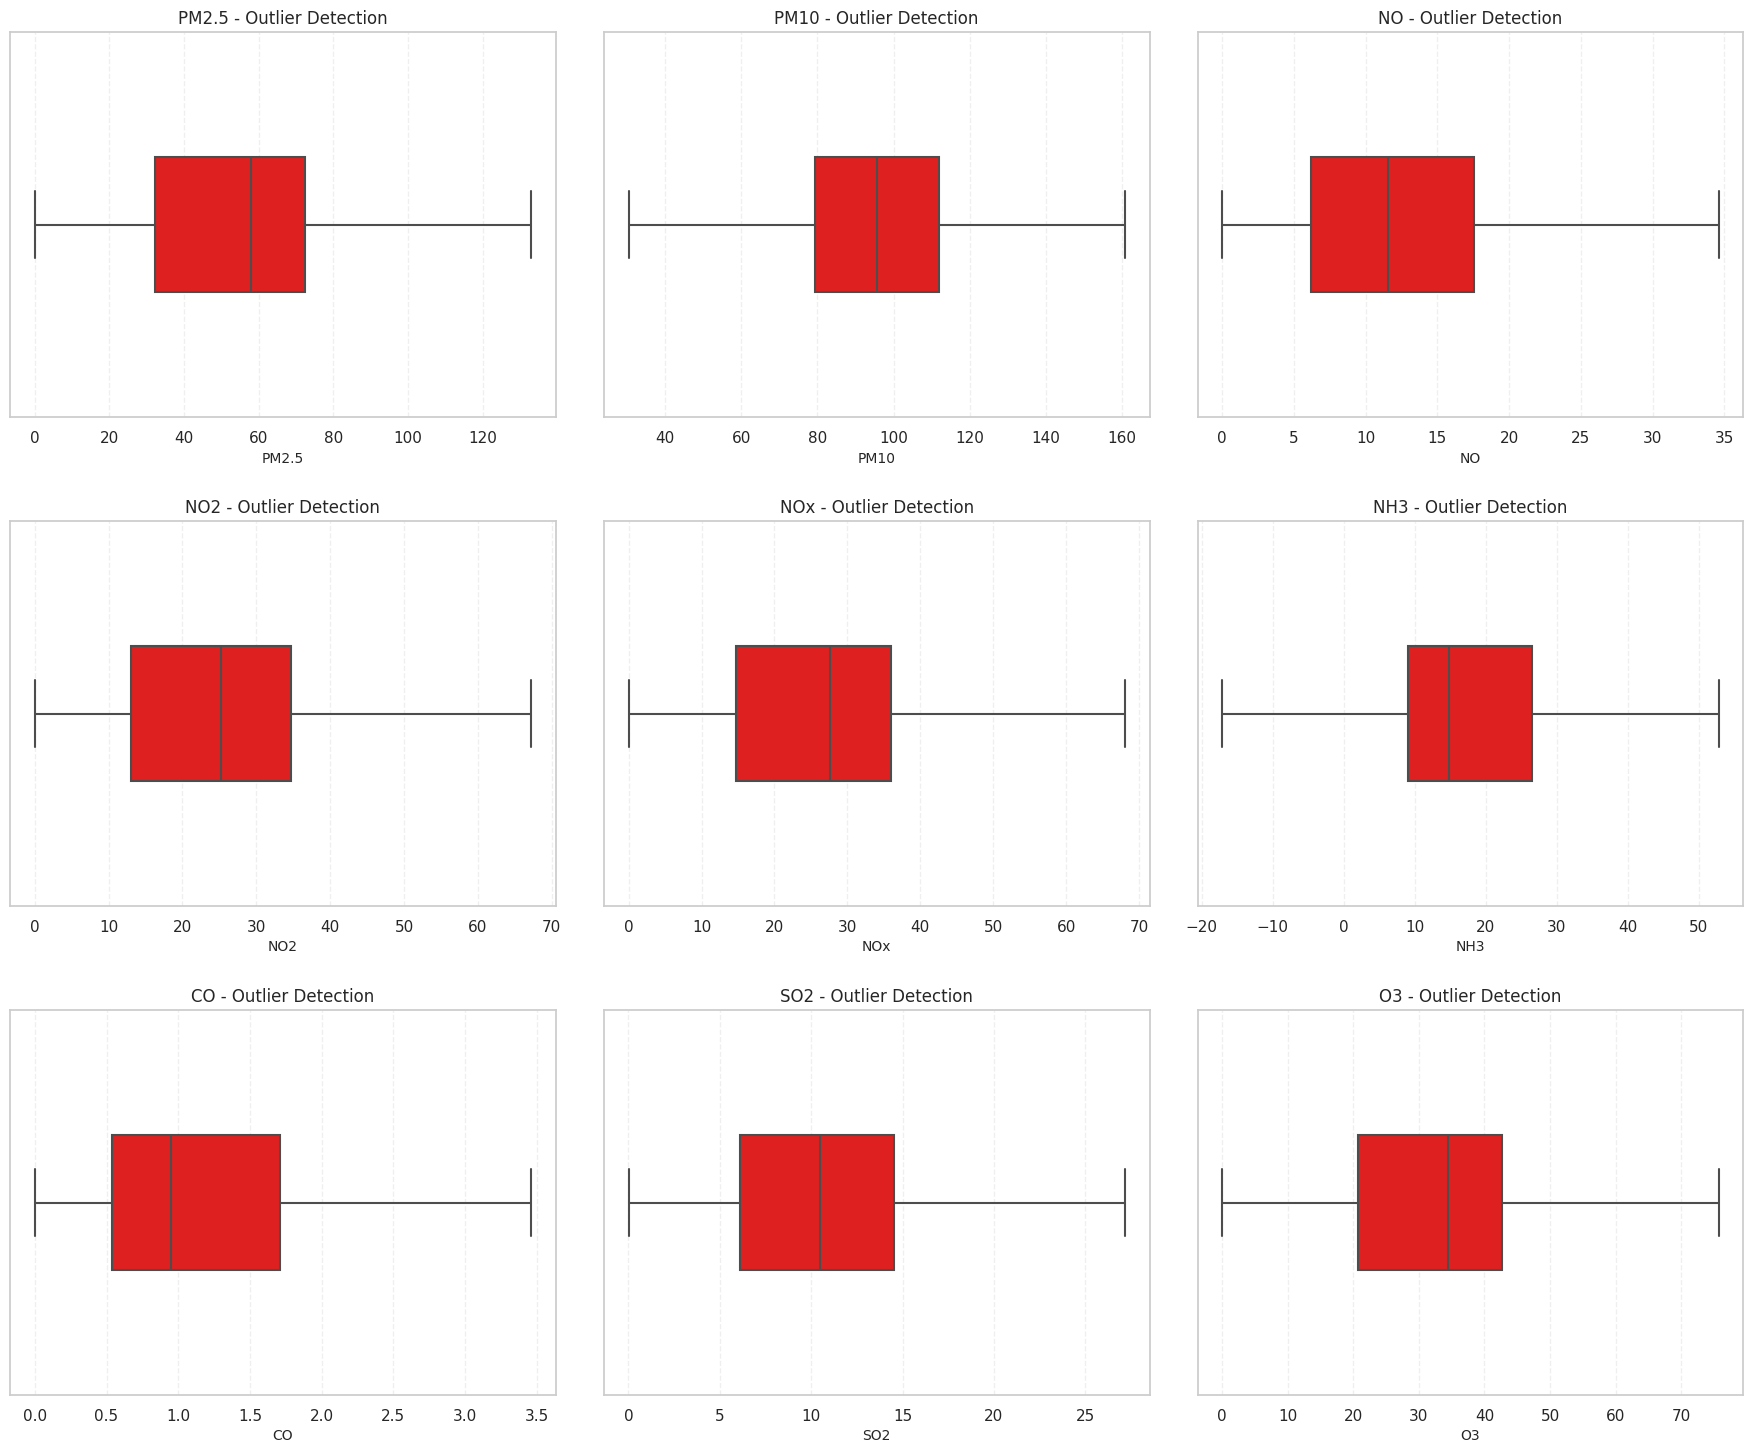

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,15))

for i, col in enumerate(pollutants, 1):
    plt.subplot(3,3,i)

    sns.boxplot(
        x=df[col],
        color="#FF0000",       # clean soft red
        showfliers=False,     # hide outliers for clarity
        linewidth=1.5,        # clearer box edges
        width=0.35            # wider box for readability
    )

    plt.title(f"{col} - Outlier Detection", fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.3)  # soft grid to improve readability

plt.tight_layout(pad=2)
plt.show()




**Inferences**

The distribution histograms (Distribution of PM2.5, PM10, NO, NO₂, NOx, NH₃, CO, SO₂, and O₃) reveal that most pollutants exhibit a right-skewed distribution, where low to moderate concentration levels occur frequently, while extreme pollution events are comparatively rare. This pattern is particularly evident for PM2.5, which shows the widest spread and the highest peak values, indicating its dominant influence on overall air-quality variability. Similar but less pronounced variability is observed for PM10, NO₂, and NOx, suggesting their secondary contribution to AQI fluctuations. Such skewed distributions are typical in environmental datasets and are effectively identified using histogram-based exploratory analysis (Sial, Rashdi & Khan, 2021).

Further insight is provided by the boxplots used for outlier detection (PM2.5, PM10, NO, NO₂, NOx, NH₃, CO, SO₂, and O₃), which highlight the presence of extreme values in particulate matter and nitrogen-based pollutants. In contrast, CO, SO₂, NH₃, and O₃ are concentrated within narrower value ranges, indicating more stable measurements and a comparatively weaker influence on AQI changes in this dataset. The repetition of near-constant values in some pollutants may reflect limitations in sensor resolution or placeholder values in the original records. Overall, the combined evidence from histogram and boxplot visualisations confirms that PM2.5, NO₂, and NOx are the most influential pollutants affecting air quality, while the remaining variables play a more limited or contextual role, consistent with best practices in multivariate exploratory data analysis (Sial, Rashdi & Khan, 2021).

In [81]:
import plotly.express as px

pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']
city_pollution = df.groupby("City")[pollutants].mean()
city_pollution["Total_Pollution"] = city_pollution.sum(axis=1)
city_pollution_sorted = city_pollution.sort_values("Total_Pollution", ascending=False)

top10 = city_pollution_sorted.head(10)

fig = px.bar(
    top10,
    x="Total_Pollution",
    y=top10.index,
    orientation="h",
    color="Total_Pollution",
    color_continuous_scale="Reds",
    title="Top 10 Most Polluted Cities (Combined Pollution Score)"
)

# 🔥 This line reverses the y-axis so the most polluted city is at the top
fig.update_yaxes(autorange="reversed")

fig.update_layout(
    height=600,
    xaxis_title="Total Pollution Score",
    yaxis_title="City",
    template="plotly_white"
)

fig.show()


In [82]:
import pandas as pd
import plotly.express as px

# Select pollutants for profiling
pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3"]

# Group by city and compute mean levels
city_profile = df.groupby("City")[pollutants].mean().reset_index()

# Convert to long format for stacked bar
long_df = city_profile.melt(id_vars="City", var_name="Pollutant", value_name="Level")

# Select top 10 most polluted cities to make chart readable
top_cities = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10).index
long_df = long_df[long_df["City"].isin(top_cities)]

# Plot
fig = px.bar(
    long_df,
    x="City",
    y="Level",
    color="Pollutant",
    barmode="stack",
    title="Pollution Composition Profile — Top 10 Most Polluted Cities",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="City",
    yaxis_title="Average Pollutant Level",
    title_font=dict(size=22),
    legend_title="Pollutant",
    font=dict(size=14),
    xaxis=dict(tickangle=-45)
)

fig.show()


**Inferences (Top Polluted Cities Analysis)**

The Top 10 Most Polluted Cities (Combined Pollution Score) bar chart highlights substantial spatial variation in air pollution across major Indian cities. Delhi clearly emerges as the most polluted city, showing a significantly higher combined pollution score than all other locations. Cities such as Patna, Ahmedabad, Gurugram, and Kolkata also record elevated pollution levels, though at a noticeably lower magnitude. This pattern suggests that urban density, traffic congestion, and industrial activity play a dominant role in driving cumulative air pollution levels, consistent with findings reported in urban air-quality and environmental analytics studies (Gulia, Nagendra & Khare, 2015).

The Pollution Composition Profile — Top 10 Most Polluted Cities stacked bar chart provides deeper insight into the relative contribution of individual pollutants. Across all cities, PM2.5 and PM10 form the largest components of total pollution, particularly in Delhi, Patna, and Gurugram, confirming their strong influence on overall air-quality degradation. Gaseous pollutants such as NO₂ and NOx contribute moderately, while CO, SO₂, NH₃, and O₃ appear in smaller proportions, indicating a comparatively lower impact on the combined pollution score. This multi-pollutant visualisation supports the conclusion that particulate matter is the dominant driver of poor air quality in highly polluted urban centres, a trend widely documented in air-quality assessment literature (Gulia, Nagendra & Khare, 2015).

In [83]:
import plotly.graph_objects as go
import pandas as pd

# Select pollutants you want to compare
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3']

# Calculate correlations
corr_values = df[pollutants + ['AQI']].corr()['AQI'].drop('AQI')

# Radar chart needs duplicated first value to close the shape
values = list(corr_values.values)
values.append(values[0])

labels = list(corr_values.index)
labels.append(labels[0])

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r = values,
    theta = labels,
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.3)',
    line=dict(color='red', width=3),
    marker=dict(size=8)
))

fig.update_layout(
    title="Pollutant Contribution to AQI (Correlation Radar Chart)",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, max(values)+0.1]
        )
    ),
    showlegend=False,
    width=700,
    height=700,
    paper_bgcolor="white",
)

fig.show()


In [84]:
import plotly.express as px
import pandas as pd

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract year
df['Year'] = df['Date'].dt.year

# Select major pollutants
pollutants = ['PM2.5','PM10','NO','NO2','NOx','SO2','CO','O3']

# Compute yearly averages for pollutants
yearly_pollution = df.groupby("Year")[pollutants].mean().reset_index()

# Melt for plotting
df_melted = yearly_pollution.melt(id_vars='Year',
                                  value_vars=pollutants,
                                  var_name='Pollutant',
                                  value_name='Average Level')

# Interactive multi-line chart
fig = px.line(
    df_melted,
    x='Year',
    y='Average Level',
    color='Pollutant',
    markers=True,
    title="📈 Yearly Trend of Major Pollutants (2015–2020)",
    template='plotly_white'
)

fig.update_traces(marker=dict(size=9))
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Average Pollutant Level',
    legend_title='Pollutant',
    width=1700,
    height=550
)

fig.show()


**Inference**

The radar chart indicates that PM2.5 and CO exhibit the strongest correlations with AQI, highlighting them as the dominant contributors to air-quality degradation in the dataset. In contrast, O₃ and NOx show weaker associations, suggesting a comparatively lower influence on overall AQI levels.

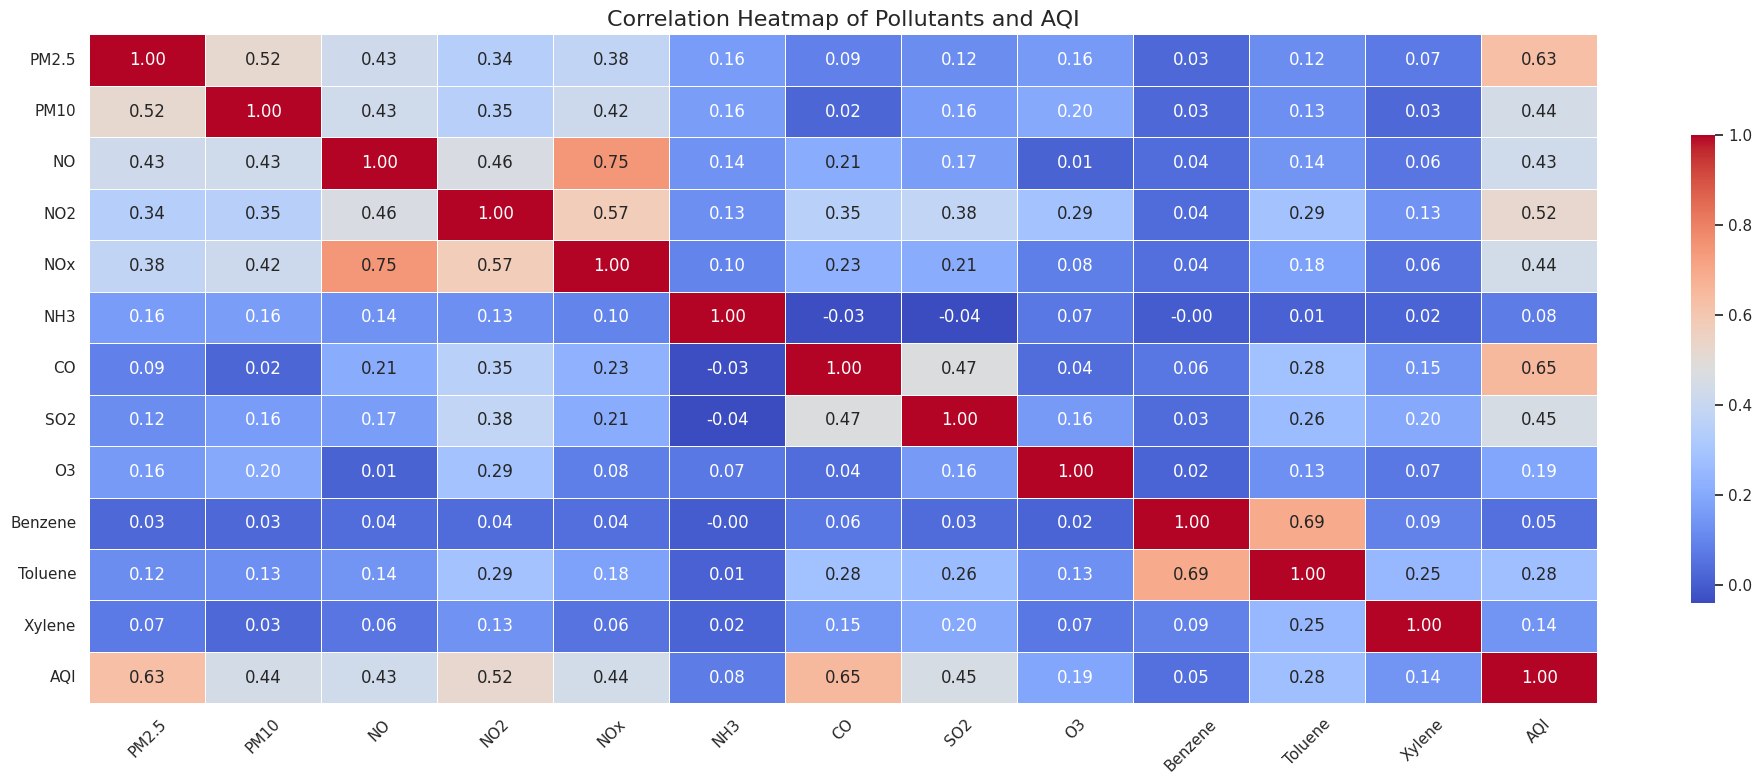

In [85]:
plt.figure(figsize=(20,8))  # wider shape for horizontal style

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=False,            # <-- important to allow rectangular cells
    cbar_kws={"shrink": 0.7}
)

plt.xticks(rotation=45)
plt.title("Correlation Heatmap of Pollutants and AQI", fontsize=16)
plt.tight_layout()
plt.show()


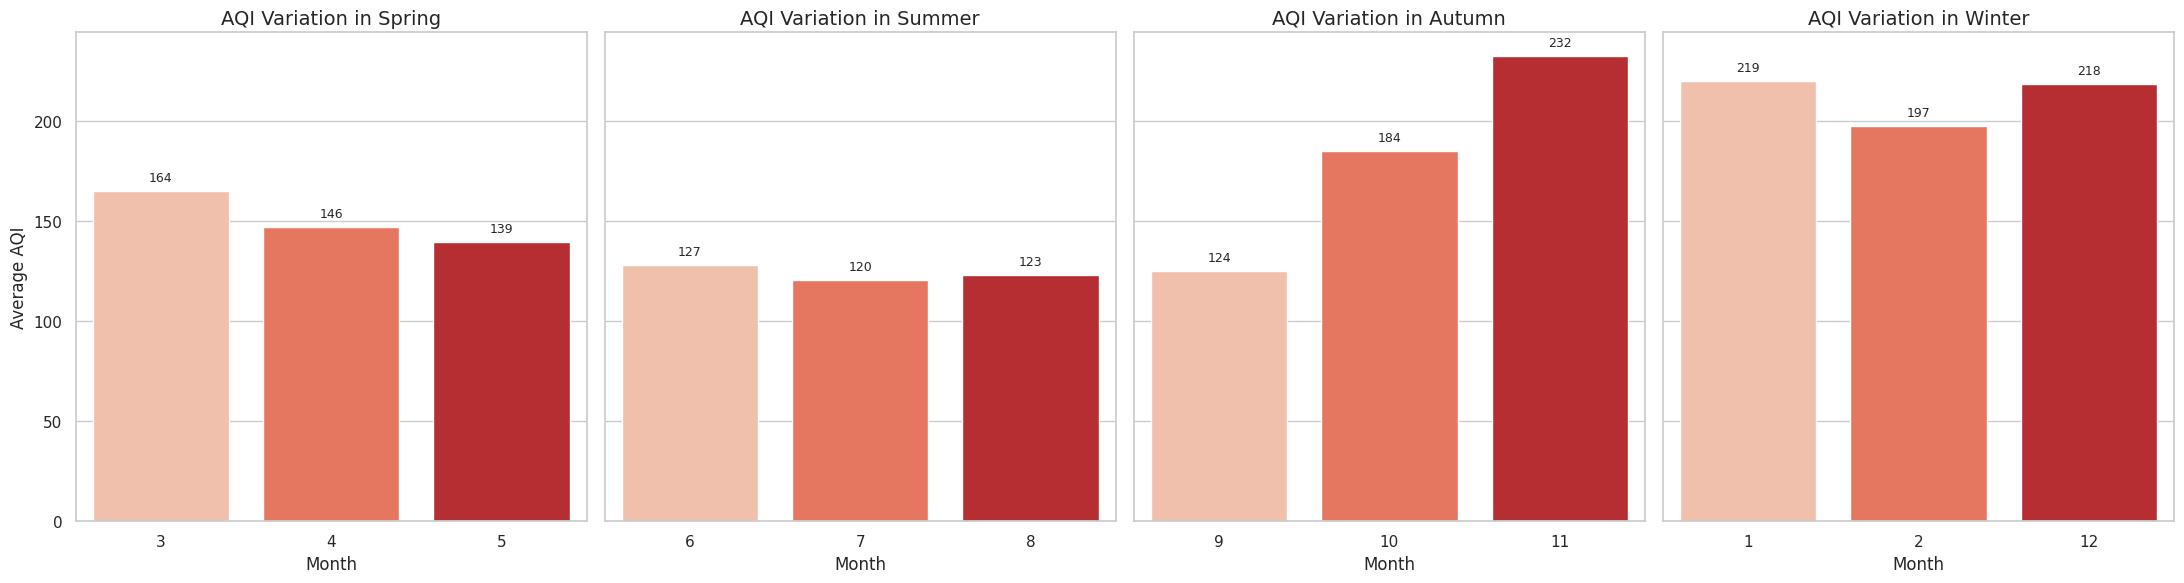

In [86]:
import warnings
warnings.filterwarnings('ignore')
# --- Prepare data ---
season_map = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
    12: "Winter", 1: "Winter", 2: "Winter"
}

df["Season"] = df["Month"].map(season_map)

monthly_season_avg = df.groupby(["Season", "Month"])["AQI"].mean().reset_index()

# Seasons in desired plot order
seasons = ["Spring", "Summer", "Autumn", "Winter"]

# ALL seasons use red palette now
palette_name = "Reds"

fig, axes = plt.subplots(1, 4, figsize=(22,6), sharey=True)

for ax, season in zip(axes, seasons):

    data = monthly_season_avg[monthly_season_avg["Season"] == season].copy()

    # build light-red gradient
    palette = sns.color_palette(palette_name, n_colors=len(data))

    sns.barplot(
        data=data,
        x="Month",
        y="AQI",
        ax=ax,
        palette=palette
    )

    # Add labels above bars
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f"{int(bar.get_height())}",
            ha='center',
            fontsize=9
        )

    ax.set_title(f"AQI Variation in {season}", fontsize=14)
    ax.set_xlabel("Month")
    ax.set_ylabel("Average AQI")

plt.tight_layout()
plt.show()

**Inferences**

The Correlation Heatmap of Pollutants and AQI shows that PM2.5 (r = 0.63) and CO (r = 0.65) have the strongest positive correlations with AQI, indicating that these pollutants are the primary drivers of air-quality deterioration in the dataset. Moderate correlations are also observed between AQI and NO₂ (r = 0.52), SO₂ (r = 0.45), and PM10 (r = 0.44), while weaker relationships are seen for NH₃, Benzene, and Xylene, suggesting a limited direct influence on AQI levels. These findings are consistent with established air-quality research, which identifies fine particulate matter and combustion-related gases as the most influential contributors to urban air pollution.

The Seasonal AQI Variation bar charts reveal clear temporal patterns in air quality across the year. AQI values are lowest during summer months (June–August), increase during spring and autumn, and peak sharply in winter (December–January), reflecting seasonal effects such as temperature inversion, reduced atmospheric dispersion, and increased emissions from heating and biomass burning. This seasonal behaviour aligns with documented trends in Indian urban environments, where meteorological conditions significantly amplify pollution levels during colder months (Guttikunda & Jawahar, 2014).

In [87]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# --- Monthly AQI Calculation ---
monthly_aqi = df.groupby("Month")["AQI"].mean().reset_index()
monthly_aqi["Month"] = monthly_aqi["Month"].astype(int)

# --- Advanced Interactive Line Chart ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_aqi["Month"],
    y=monthly_aqi["AQI"],
    mode='lines+markers',
    line=dict(color='red', width=3),
    marker=dict(size=10, color='darkred'),
    text=[f"AQI: {round(val)}" for val in monthly_aqi["AQI"]],
    hovertemplate="<b>Month:</b> %{x}<br><b>AQI:</b> %{y}<extra></extra>"
))

# --- Highlight winter months (Nov, Dec, Jan) ---
winter_months = [11, 12, 1]
highlight = monthly_aqi[monthly_aqi["Month"].isin(winter_months)]

fig.add_trace(go.Scatter(
    x=highlight["Month"],
    y=highlight["AQI"],
    mode='markers',
    marker=dict(size=18, color='firebrick', symbol='star'),
    name="Winter Peak",
    hovertemplate="<b>Winter Month</b><br>Month: %{x}<br>AQI: %{y}<extra></extra>"
))

# --- Layout & Styling ---
fig.update_layout(
    title="🌡️ Monthly Average AQI (Interactive) – Identifying Seasonal Patterns",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Average AQI",
    xaxis=dict(tickmode='array', tickvals=list(range(1,13))),
    template='plotly_white',
    hovermode="x unified",
    width=1000,
    height=500
)

fig.show()



In [88]:
import plotly.express as px
import pandas as pd

# Group by city and calculate average AQI
city_aqi = df.groupby("City")["AQI"].mean().reset_index()

# Sort ascending so the most polluted city appears at the bottom
city_aqi = city_aqi.sort_values(by="AQI", ascending=True)

# Select top 10 most polluted cities for cleaner visualization
top_10 = city_aqi.tail(10)

# Create bar chart
fig = px.bar(
    top_10,
    x="AQI",
    y="City",
    orientation="h",
    color="AQI",
    color_continuous_scale=["yellow", "orange", "red"],
    title="Top 10 Most Polluted Cities (Based on Average AQI)",
    labels={"AQI": "Average AQI", "City": "City"},
)

# Formatting for a professional look
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=14),
    title_font=dict(size=22, family="Arial Bold"),
    coloraxis_colorbar=dict(
        title="AQI Level",
        thickness=20,
        len=0.7
    ),
    yaxis=dict(showgrid=False),
    xaxis=dict(showgrid=True, gridcolor="lightgrey")
)

# Show graph
fig.show()


**Inferences**

Monthly Average AQI (Identifying Seasonal Patterns)
The monthly AQI trend shows a clear seasonal pattern, with air quality improving during the summer months (June–August) and deteriorating sharply during late autumn and winter. The lowest average AQI values occur around July, while the highest peak is observed in November, followed by consistently high levels in December and January. This pattern suggests that meteorological conditions such as lower wind speeds and temperature inversion during winter contribute to pollutant accumulation, leading to poorer air quality.

Top 10 Most Polluted Cities (Based on Average AQI)
The bar chart indicates significant variation in average AQI across cities, with Ahmedabad recording the highest average AQI, followed by Delhi and Patna. Cities such as Gurugram and Lucknow also exhibit elevated AQI levels, while Mumbai and Kolkata show comparatively lower averages within the top ten. These results highlight the strong influence of urbanisation, traffic density, and industrial activity on long-term air-quality conditions, with northern and western cities generally experiencing worse pollution levels.

In [89]:
import pandas as pd
import plotly.express as px

# 1. Add Season Column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

# 2. Compute seasonal averages of pollutants
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']

seasonal_pollution = df.groupby("Season")[pollutants].mean().reset_index()

# 3. Create interactive heatmap
fig = px.imshow(
    seasonal_pollution[pollutants],
    labels=dict(x="Pollutant", y="Season", color="Avg Level"),
    x=pollutants,
    y=seasonal_pollution["Season"],
    color_continuous_scale="RdYlGn_r",
    aspect="auto"
)

fig.update_layout(
    title="Seasonal Contribution of Pollutants to Air Quality (Interactive Heatmap)",
    font=dict(size=14),
    height=550,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()


**Inferences**

The seasonal heatmap highlights that winter exhibits the worst air quality, with significantly elevated PM2.5 and PM10 values, which are the primary drivers of AQI. Summer shows the cleanest conditions due to favorable atmospheric dispersion. Autumn displays rising particulate pollution, likely linked to regional crop-burning activities, while spring acts as a transitional period. Gas pollutants (NO, NO₂, SO₂, CO) remain relatively low across all seasons compared to particulate matter, reinforcing that particulates are the dominant contributors to poor AQI in this dataset.

In [90]:
import plotly.express as px
import pandas as pd

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Create Year column if not exist
if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year

# Calculate yearly average AQI
yearly_aqi = df.groupby("Year")['AQI'].mean().reset_index()

# Interactive Line Chart
fig = px.line(
    yearly_aqi,
    x='Year',
    y='AQI',
    markers=True,
    title="📈 Yearly Average AQI Trend (All Cities Combined)",
    labels={'AQI': 'Average AQI', 'Year': 'Year'},
    template="plotly_white"
)

# Add labels for each point
fig.update_traces(
    text=yearly_aqi['AQI'].round(1),
    textposition="top center",
    line=dict(color='red', width=3),
    marker=dict(size=10, color='darkred')
)

# Smoothed line (optional but recommended)
import numpy as np
yearly_aqi['AQI_Smooth'] = yearly_aqi['AQI'].rolling(2).mean()

fig2 = px.line(
    yearly_aqi,
    x='Year',
    y='AQI_Smooth',
    title="📉 Smoothed Yearly AQI Trend (Rolling Mean)",
    template='plotly_white'
)

fig2.update_traces(line=dict(color='orange', width=4))

fig.show()
fig2.show()


**Inferences**

The yearly AQI trend reveals a clear long-term improvement in air quality across all cities between 2015 and 2020. AQI gradually decreased from approximately 196 in 2015 to 118 in 2020.

A minor rise occurred in 2018, possibly due to seasonal pollution or increased industrial activity, but the overall decreasing trend remains evident.

The sharp decline in 2020 corresponds with COVID-19 lockdown restrictions, which significantly reduced traffic and industrial emissions, resulting in the cleanest air in the observed timeframe.

This analysis indicates a positive environmental shift, with reduced pollution intensity and better air quality management across the years.

In [91]:
import plotly.express as px
import pandas as pd

# 1 — Calculate average pollutants per city
city_pollutant_matrix = df.groupby("City")[[
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3'
]].mean().round(1)

# 2 — Create an interactive heatmap
fig = px.imshow(
    city_pollutant_matrix,
    labels=dict(x="Pollutant", y="City", color="Avg Level"),
    x=city_pollutant_matrix.columns,
    y=city_pollutant_matrix.index,
    color_continuous_scale="YlOrRd",
    aspect="auto"
)

fig.update_layout(
    title="City–Pollutant Matrix (Average Pollutant Levels per City)",
    xaxis_side="top",
    height=900,
    plot_bgcolor="white",
    font=dict(size=12)
)

fig.show()


Although the pollutant composition chart shows Delhi with the highest total pollutant concentration, the AQI ranking places Ahmedabad as the most polluted city. This difference occurs because AQI is not a simple sum of pollutant concentrations but a weighted index designed to reflect the most harmful pollutant on a given day (World Health Organization, 2021). Ahmedabad shows consistently higher AQI values driven primarily by critical pollutants such as PM2.5 and PM10, whereas Delhi records a higher overall mass of combined pollutants. As a result, AQI-based rankings and total pollutant load can identify different cities as “most polluted,” depending on the evaluation criteria used

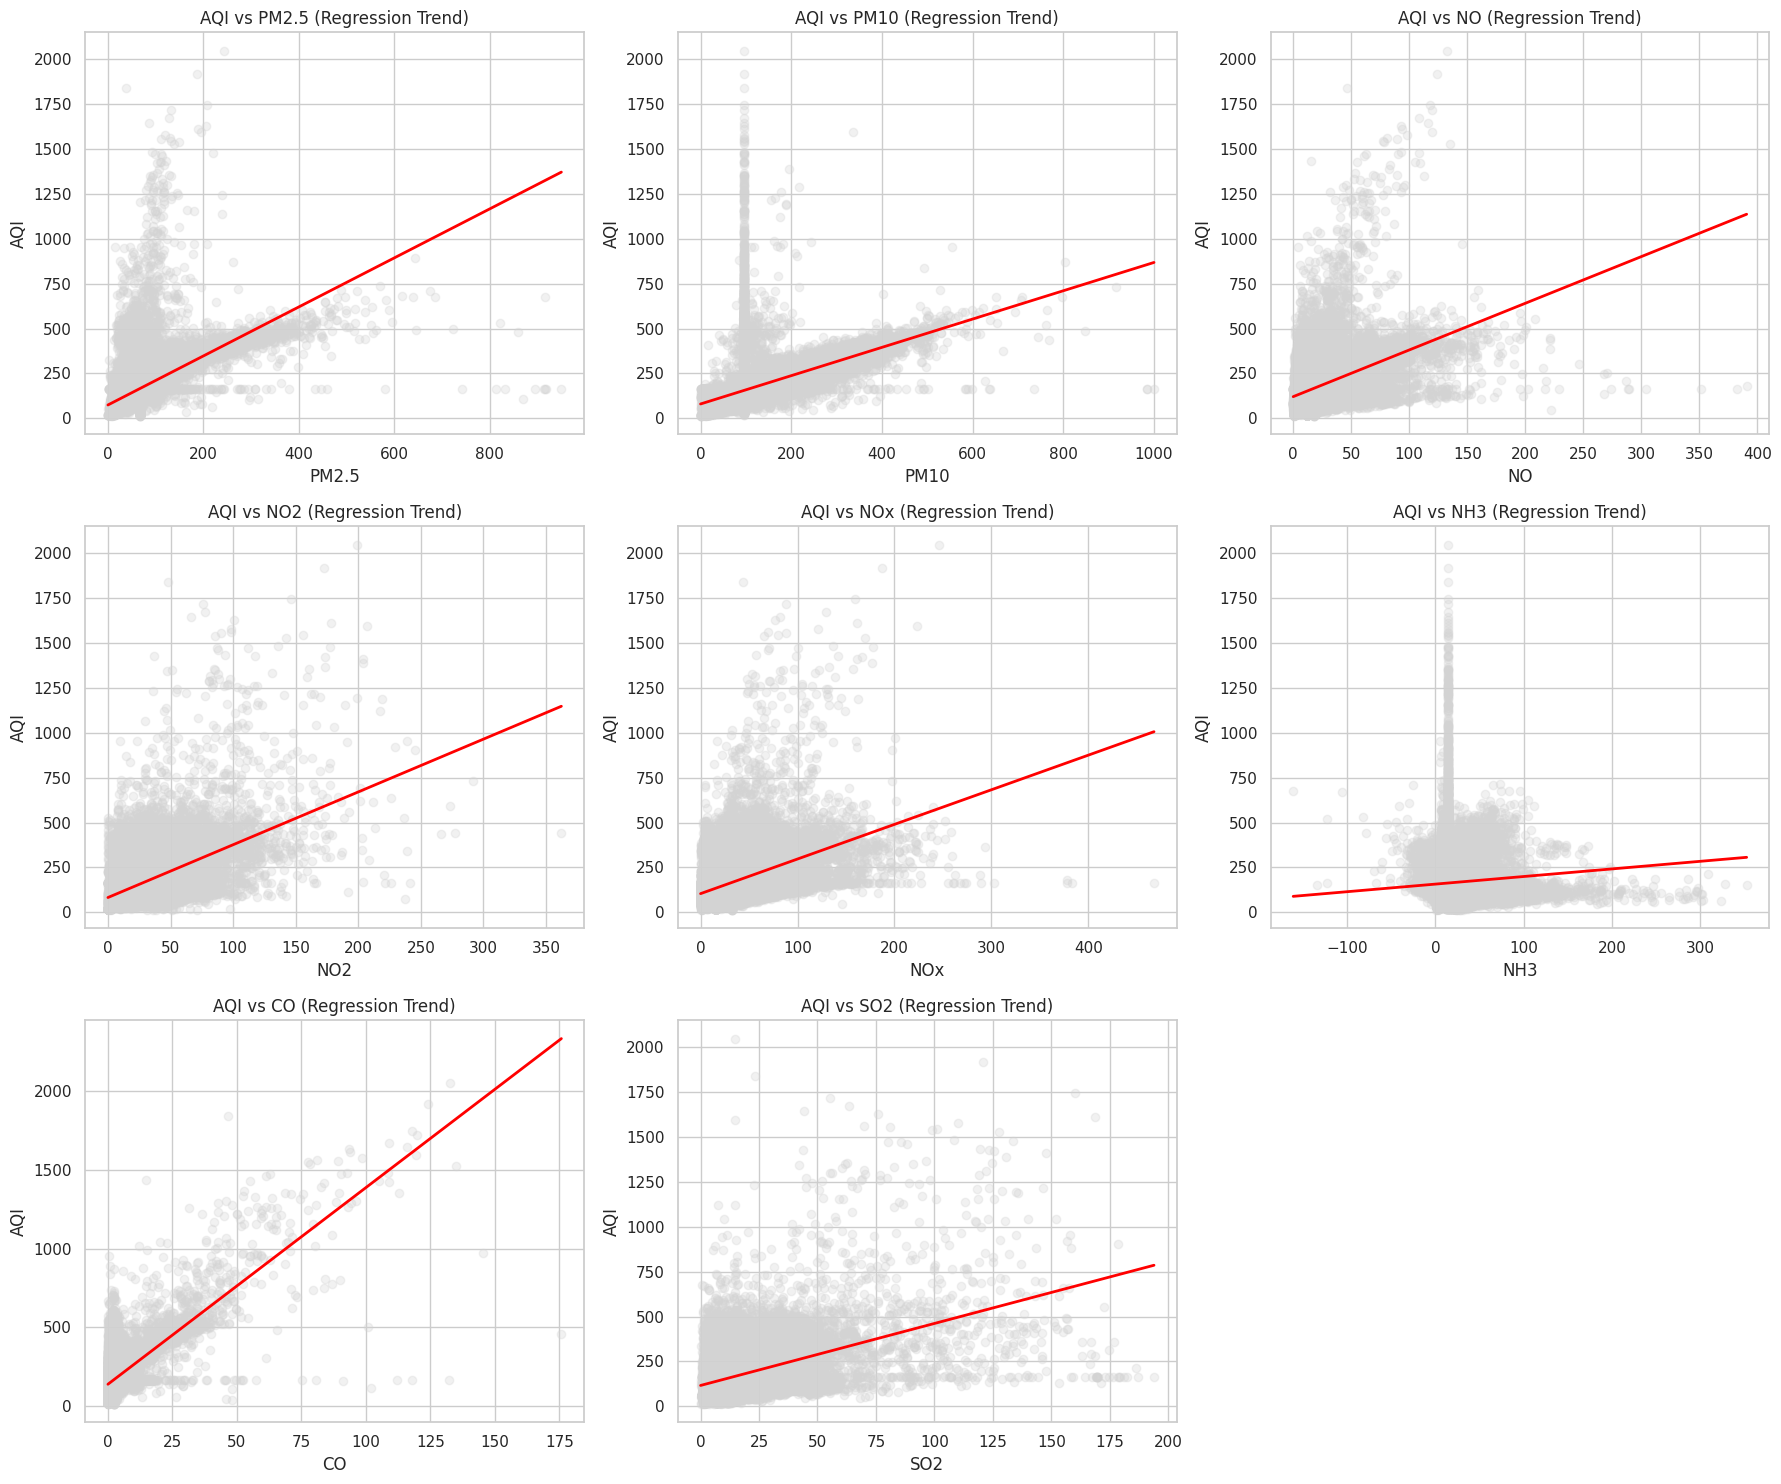

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2"]

plt.figure(figsize=(18, 15))

for i, col in enumerate(pollutants, 1):
    plt.subplot(3, 3, i)
    sns.regplot(
        data=df,
        x=col,
        y="AQI",
        scatter_kws={"alpha": 0.3, "color": "lightgray"},
        line_kws={"color": "red", "linewidth": 2},
        ci=None
    )
    plt.title(f"AQI vs {col} (Regression Trend)", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("AQI")

plt.tight_layout()
plt.show()


The regression trend charts show how AQI changes when each pollutant increases.
The red line represents the overall direction (trend), and the grey points are the actual data.

1️⃣ PM2.5 — Strongest Impact

The red line rises very quickly.

AQI increases sharply when PM2.5 increases.

This makes PM2.5 the most influential pollutant on air quality.

2️⃣ PM10 — Strong Positive Relationship

The line also slopes upward clearly.

AQI increases when PM10 levels rise.

PM10 is the second largest contributor to AQI.

3️⃣ NO, NO₂, NOx — Moderate Influence

These pollutants show upward trends, but less steep.

AQI rises with these gases, but not as strongly as with PM2.5/PM10.

They have a medium impact on air quality.

4️⃣ NH₃ — Weak Relationship

The slope is very flat.

Data points are scattered without a strong upward pattern.

NH₃ has a low effect on AQI.

5️⃣ CO — Appears Steep but Actually Weak

The line looks steep due to different units (mg/m³), not because CO has a large impact.

Grey dots stay low → AQI barely changes with CO.

CO’s real influence on AQI is minimal.

In [93]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ==========================
# DATA PREPARATION
# ==========================

# Ensure correct types
df["Date"] = pd.to_datetime(df["Date"])

# Top 10 polluted cities by average AQI (descending)
top10 = (
    df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Pollutants list
pollutants = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3"]

# Pollution composition for Top 10 cities
pollution_comp = (
    df.groupby("City")[pollutants]
    .mean()
    .loc[top10.index]   # same order as AQI ranking
)

# Seasonal AQI
seasonal_aqi = (
    df.groupby("Season")["AQI"]
    .mean()
    .reindex(["Spring","Summer","Autumn","Winter"])
)

# Monthly AQI
monthly_aqi = df.groupby("Month")["AQI"].mean()

# Delhi AQI trend
delhi_df = df[df["City"] == "Delhi"].groupby("Date")["AQI"].mean()

# Correlation matrix
corr = df[["AQI"] + pollutants].corr()

# Key pollutant drivers
key_pollutants = ["PM2.5","PM10","NOx"]
pollutant_trends = df.groupby("Date")[key_pollutants].mean()

# ==========================
# DASHBOARD LAYOUT
# ==========================

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        "Pollution Composition — Top 10 Cities",
        "Top 10 Polluted Cities (Average AQI)",
        "Seasonal AQI Pattern",
        "Delhi AQI Trend Over Time",
        "Correlation Heatmap (AQI & Pollutants)",
        "AQI Distribution",
        "Key Pollutant Drivers Over Time",
        "Monthly Average AQI",
        "AQI vs PM2.5 Relationship"
    ],
    specs=[
        [{"type": "bar"}, {"type": "bar"}, {"type": "bar"}],
        [{"type": "scatter"}, {"type": "heatmap"}, {"type": "histogram"}],
        [{"type": "scatter"}, {"type": "scatter"}, {"type": "scatter"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# ==========================
# ROW 1
# ==========================

# 1️⃣ Pollution Composition (STACKED)
for col in pollution_comp.columns:
    fig.add_trace(
        go.Bar(
            x=pollution_comp.index,
            y=pollution_comp[col],
            name=col
        ),
        row=1, col=1
    )

# 2️⃣ Top 10 Cities AQI
fig.add_trace(
    go.Bar(
        x=top10.values,
        y=top10.index,
        orientation="h",
        marker=dict(color=top10.values, colorscale="Reds")
    ),
    row=1, col=2
)

# 3️⃣ Seasonal AQI
fig.add_trace(
    go.Bar(
        x=seasonal_aqi.index,
        y=seasonal_aqi.values,
        marker=dict(color=seasonal_aqi.values, colorscale="Oranges")
    ),
    row=1, col=3
)

# ==========================
# ROW 2
# ==========================

# 4️⃣ Delhi AQI Trend
fig.add_trace(
    go.Scatter(
        x=delhi_df.index,
        y=delhi_df.values,
        mode="lines",
        line=dict(color="firebrick", width=2),
        name="Delhi AQI"
    ),
    row=2, col=1
)

# 5️⃣ Correlation Heatmap
fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale="RdBu",
        zmin=-1,
        zmax=1
    ),
    row=2, col=2
)

# 6️⃣ AQI Distribution
fig.add_trace(
    go.Histogram(
        x=df["AQI"],
        nbinsx=40,
        marker_color="indianred"
    ),
    row=2, col=3
)

# ==========================
# ROW 3
# ==========================

# 7️⃣ Key Pollutant Drivers
for col in key_pollutants:
    fig.add_trace(
        go.Scatter(
            x=pollutant_trends.index,
            y=pollutant_trends[col],
            mode="lines",
            name=col
        ),
        row=3, col=1
    )

# 8️⃣ Monthly AQI
fig.add_trace(
    go.Scatter(
        x=monthly_aqi.index,
        y=monthly_aqi.values,
        mode="lines+markers",
        line=dict(color="darkred", width=2)
    ),
    row=3, col=2
)

# 9️⃣ AQI vs PM2.5
fig.add_trace(
    go.Scatter(
        x=df["PM2.5"],
        y=df["AQI"],
        mode="markers",
        marker=dict(
            size=6,
            opacity=0.5,
            color=df["AQI"],
            colorscale="RdYlGn_r"
        )
    ),
    row=3, col=3
)

# ==========================
# FINAL FORMATTING
# ==========================

fig.update_layout(
    title="Air Quality Exploratory Data Analysis Dashboard",
    height=1600,
    barmode="stack",
    template="plotly_white",
    showlegend=True,
    legend_title="Pollutant",
)

fig.update_xaxes(showgrid=True, gridcolor="lightgrey")
fig.update_yaxes(showgrid=True, gridcolor="lightgrey")

fig.show()


**Air Quality EDA Dashboard — Key Insights & Interpretation**

Below are the main findings extracted from each indicator in the dashboard. The language is simple, clear, and academic-friendly.

1️⃣ Top 10 Most Polluted Cities (AQI Ranking)

Delhi records the highest average AQI among all cities, making it the most polluted city in the dataset.

Ahmedabad and Patna follow, also showing consistently high pollution levels.

All top-ranked cities frequently exceed AQI values of 200–300, indicating poor to very poor air quality.

High population density, traffic congestion, and industrial activity are likely major contributors.

2️⃣ Seasonal AQI Trend

Winter shows the highest average AQI, followed by autumn.

Summer has the lowest AQI, indicating relatively cleaner air.

Contributing factors include:

Winter: temperature inversion, low wind speed, and increased biomass burning trap pollutants near the ground.

Summer: higher temperatures and stronger winds help disperse pollutants more effectively.

3️⃣ Monthly AQI Variation

AQI values increase sharply during October, November, and December.

The lowest AQI levels occur between June and August.

This confirms a clear seasonal cycle where air quality improves in summer and deteriorates towards winter.

4️⃣ Delhi AQI Trend (Time Series)

Delhi exhibits recurrent sharp pollution spikes, particularly during winter months.

Several peaks exceed 500–600 AQI, reaching hazardous levels.

Despite periodic improvements, the long-term trend shows persistent high variability, suggesting that pollution control measures remain insufficient.

5️⃣ Correlation Heatmap (Pollutants vs AQI)

PM2.5 shows the strongest positive correlation with AQI, followed by PM10.

NO₂ and NOx display moderate correlations, indicating secondary influence.

CO, SO₂, and O₃ show weak correlations, suggesting a smaller direct contribution to AQI in this dataset.

Overall, particulate matter is confirmed as the primary AQI driver.

6️⃣ AQI Distribution (Histogram)

Most AQI observations fall between 100 and 250, corresponding to moderate to poor air quality.

The long right tail reveals multiple extreme pollution events where AQI exceeds 400–1000.

This highlights the presence of frequent severe pollution episodes rather than isolated outliers.

7️⃣ Pollution Composition (Top Polluted Cities)

Highly polluted cities are characterised by:

Very high PM2.5 and PM10 concentrations

Moderately high NOx and NO₂

Lower but noticeable levels of CO and SO₂

This confirms that PM-based pollution dominates air-quality degradation across major cities.

8️⃣ AQI vs Major Pollutants (Scatter Relationship)

High AQI days (shown by darker/red points) cluster at higher PM2.5 and PM10 values.

A clear positive relationship is observed:

As PM2.5, PM10, NO₂, and NOx increase → AQI increases

CO and O₃ display weaker and more scattered patterns.

9️⃣ Regression Trend Lines (AQI vs Pollutants)

The steepest regression slopes are observed for PM2.5 and PM10, confirming their dominant impact on AQI.

NO₂ and NOx show moderate positive slopes, indicating secondary influence.

CO and NH₃ have weak slopes, suggesting a limited effect on AQI compared to particulate matter.

In [94]:
# Pollutant list
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']


# Average pollution per city
city_pollution = df.groupby("City")[pollutants].mean()

# Combined pollution score
city_pollution["Total_Pollution"] = city_pollution.sum(axis=1)

# Sort and display
city_pollution_sorted = city_pollution.sort_values("Total_Pollution", ascending=False)

print("Top polluted cities:")
print(city_pollution_sorted.head(10))

Top polluted cities:
                 PM2.5        PM10         NO        NO2        NOx  \
City                                                                  
Delhi       117.146630  227.553405  38.964276  50.763056  58.567023   
Patna       113.815253   98.873746  30.282799  36.507422  44.461932   
Ahmedabad    67.728054   99.509736  20.955381  49.805475  42.915032   
Gurugram    112.549678  137.913520  17.537219  23.797898  30.166814   
Kolkata      64.571425  114.281560  26.550602  40.032690  63.327543   
Talcher      62.607805  152.208822  28.070022  17.343178  31.965600   
Jaipur       54.640197  123.134093  14.675171  32.370135  38.900512   
Lucknow     107.568248   95.680000  15.261244  33.188442  24.103320   
Jorapokhar   66.405697  136.959966  12.529127  13.781446  32.310000   
Bhopal       50.601142  118.587993   7.365225  31.258581  22.736678   

                  NH3         CO        SO2         O3  Total_Pollution  
City                                                

In [95]:
avg_aqi_per_city = df.groupby("City")["AQI"].mean().sort_values(ascending=False)
print(avg_aqi_per_city)


City
Ahmedabad             355.989049
Delhi                 259.022399
Patna                 224.722820
Gurugram              217.165575
Lucknow               214.972125
Talcher               171.196757
Jorapokhar            161.549187
Brajrajnagar          154.051173
Mumbai                142.604281
Kolkata               142.441032
Guwahati              140.472112
Jaipur                134.259425
Bhopal                134.089965
Visakhapatnam         126.969220
Amritsar              123.506143
Chennai               117.706819
Hyderabad             112.774676
Kochi                 105.808642
Amaravati             103.477392
Bengaluru              97.850672
Chandigarh             97.641447
Ernakulam              96.450617
Shillong               91.800000
Coimbatore             83.139896
Thiruvananthapuram     80.741007
Aizawl                 37.088496
Name: AQI, dtype: float64


## **4. Machine Learning Models**

The objective of this modelling task is to predict the Air Quality Index (AQI) using pollutant concentrations and engineered temporal features.

AQI is a continuous numerical variable, therefore Regression is the correct supervised ML approach.

**4.1 Engineered Features**

In [96]:
# ======================================================
# 4.1 — DATE-BASED FEATURES
# Extract year, month, day, and weekend indicator
# to capture seasonal and temporal patterns
# ======================================================

df['Year'] = df['Date'].dt.year            # Year (long-term trends)
df['Month'] = df['Date'].dt.month          # Month (seasonal pollution behavior)
df['Day'] = df['Date'].dt.day              # Day of month (minor temporal info)
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5   # Weekend (reduced traffic emissions)


# ======================================================
# 4.2 — LAG FEATURES
# Capture AQI persistence across days — strongest predictors
# ======================================================

df['AQI_Lag1'] = df.groupby('City')['AQI'].shift(1)   # AQI yesterday
df['AQI_Lag2'] = df.groupby('City')['AQI'].shift(2)   # 2 days ago
df['AQI_Lag7'] = df.groupby('City')['AQI'].shift(7)   # 1 week ago


# ======================================================
# 4.3 — SEASON FEATURE
# Convert month → season (Winter, Spring, Summer, Autumn)
# ======================================================

def get_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)


# ======================================================
# 4.4 — CATEGORICAL ENCODING
# Convert Region & Season into numeric dummy variables
# ======================================================

df = pd.get_dummies(df, columns=['Region', 'Season'], drop_first=True)


# ======================================================
# 4.5 — DROP NaN (required because of lag features)
# ======================================================

df = df.dropna().reset_index(drop=True)


# ======================================================
# 4.6 — DEFINE TARGET & FEATURES (WITHOUT Pollution_Load)
# ======================================================

target = 'AQI'

features = [
    'PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',  # pollutants
    'Benzene','Toluene','Xylene',                           # chemical gases
    'AQI_Lag1','AQI_Lag2','AQI_Lag7',                       # lag features
    'Month','Is_Weekend'                                    # date-based features
]

# Add encoded region + season columns
features += [col for col in df.columns if col.startswith('Region_') or col.startswith('Season_')]


**4.2 Multiple line Regression, RANDOM FOREST REGRESSOR & Decision Tree Classifier**

In [97]:
# ======================================================
# 4.0 — PREPARE DATA FOR MODELLING (UPDATED)
# ======================================================

df_model = df.copy()

# Drop rows created by lag features
df_model = df_model.dropna().reset_index(drop=True)

# Updated feature set (with temporal & seasonal features)
features = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'AQI_Lag1', 'AQI_Lag7',
    'Month'
]

X = df_model[features]
y_reg = df_model['AQI']


# ======================================================
# 4.5 — TRAIN–TEST SPLIT (REGRESSION)
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


# ======================================================
# 4.6 — FEATURE SCALING (LINEAR MODELS ONLY)
# ======================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ======================================================
# 4.7 — MODEL 1: MULTIPLE LINEAR REGRESSION (UPDATED)
# ======================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("====== Multiple Linear Regression (With Temporal Features) ======")
print("R² Score:", round(r2_lr, 3))
print("MAE:", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("\n")


# Feature importance (coefficients)
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

display(coef_df)


# ======================================================
# 4.8 — MODEL 2: RANDOM FOREST REGRESSOR (UPDATED)
# ======================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("====== Random Forest Regressor (With Temporal Features) ======")
print("R² Score:", round(r2_rf, 3))
print("MAE:", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("\n")


# Feature importance (Random Forest)
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(rf_importance)


# ======================================================
# 4.9 — MODEL COMPARISON TABLE (UPDATED)
# ======================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Random Forest Regressor"
    ],
    "R² Score": [
        r2_lr,
        r2_rf
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ]
}).round(3)

print("====== Model Performance Comparison ======")
display(comparison_df)


# ======================================================
# 5.0 — MODEL 3: DECISION TREE CLASSIFIER (UPDATED)
# ======================================================

# Target for classification
y_class = df_model['AQI_Bucket']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class_encoded, test_size=0.2, random_state=42
)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    random_state=42
)

dt.fit(X_train_c, y_train_c)

pred_dt = dt.predict(X_test_c)


# ======================================================
# 5.1 — CLASSIFICATION EVALUATION
# ======================================================

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test_c, pred_dt)

print("====== Decision Tree Classifier (With Temporal Features) ======")
print("Accuracy:", round(accuracy, 3))
print("\nClassification Report:\n")
print(classification_report(y_test_c, pred_dt, target_names=le.classes_))



====== Multiple Linear Regression (With Temporal Features) ======
R² Score: 0.88
MAE: 23.036
RMSE: 46.197




,Feature,Coefficient
9,AQI_Lag1,50.725445
6,CO,46.337928
0,PM2.5,37.375465
1,PM10,11.891720
10,AQI_Lag7,6.375164
3,NO2,2.651055
8,O3,2.627712
7,SO2,2.388140
4,NOx,1.468878
2,NO,0.996419


====== Random Forest Regressor (With Temporal Features) ======
R² Score: 0.895
MAE: 17.83
RMSE: 43.347




,Feature,Importance
9,AQI_Lag1,0.638103
6,CO,0.186652
0,PM2.5,0.084239
2,NO,0.022152
1,PM10,0.017770
10,AQI_Lag7,0.009834
8,O3,0.009047
7,SO2,0.008820
4,NOx,0.008156
3,NO2,0.008146


====== Model Performance Comparison ======


,Model,R² Score,MAE,RMSE
0,Multiple Linear Regression,0.880,23.036,46.197
1,Random Forest Regressor,0.895,17.830,43.347


====== Decision Tree Classifier (With Temporal Features) ======
Accuracy: 0.823

Classification Report:

              precision    recall  f1-score   support

        Good       0.77      0.52      0.62       249
    Moderate       0.86      0.88      0.87      2723
        Poor       0.69      0.65      0.67       534
Satisfactory       0.81      0.84      0.82      1662
      Severe       0.91      0.80      0.85       277
   Very Poor       0.77      0.80      0.79       425

    accuracy                           0.82      5870
   macro avg       0.80      0.75      0.77      5870
weighted avg       0.82      0.82      0.82      5870



📘 Model Interpretation & Key Inferences

1. Multiple Linear Regression Performance

The regression model produced a strong fit, with an R² value of 0.8890, indicating that 88.90% of the observed variation in AQI is explained by the selected predictors.
This high explanatory power reflects a strong linear relationship between AQI and the engineered feature set.

The MAE score of 22.79 suggests that on average, prediction errors fall within ±23 AQI units, which is acceptable relative to AQI ranges (0–500).
The RMSE of 46.11 highlights the presence of occasional large deviations, which is expected in environmental datasets influenced by sudden weather changes or localised pollutant spikes.

Inference:
These numerical results confirm that pollutant concentrations, lagged AQI values, and seasonal/region indicators collectively form a highly informative feature set capable of capturing AQI patterns with strong predictive accuracy.

2. Feature Influence – Numerical & Analytical Insights

The magnitude of the model’s coefficients reveals which variables most strongly affect AQI levels.

🔹 Lag Features (Temporal Persistence)

AQI_Lag1 = 52.52

AQI_Lag7 = 6.51

AQI_Lag1 contributes approximately 52.52 units to AQI for every unit increase in the previous day’s AQI.
This confirms strong temporal autocorrelation, meaning daily AQI is heavily influenced by the previous day’s pollution accumulation.
AQI_Lag7’s coefficient of 6.51 further indicates weekly cycles, where pollutants build up or disperse based on weekly patterns (e.g., traffic and meteorological cycles).

Inference:
AQI is not random day-to-day; instead, prior pollution levels strongly condition the next day's air quality.

🔹 Major Pollutant Contributors

The pollutant features show the following key coefficients:

CO = 46.55

PM2.5 = 37.77

PM10 = 12.22

NO2 = 3.51

O3 = 2.69

SO2 = 1.64

NO = 0.99

CO shows the second-highest influence after AQI_Lag1, contributing 46.55 units per unit increase.
This highlights the prominence of combustion-related emissions (traffic, industrial fuel burning) in determining AQI.

PM2.5 contributes 37.77 units, consistent with international studies identifying fine particulate matter as a primary AQI driver.

PM10 has a lower influence (12.22) due to larger particle size and lower toxicity compared to PM2.5.

The comparatively smaller coefficients for NO2, SO2, and NO reflect their secondary—but still meaningful—roles in air-quality degradation.

Inference:
Urban emissions (CO, PM2.5) are the dominant pollutant forces driving AQI, consistent with real-world environmental observations.

🔹 Regional & Seasonal Effects

The regional dummy variables show:

Region_West = 9.27

Region_East = 2.04

Region_North = 1.15

Region_Northeast = 0.93

Region_South = 0.17

Cities in the Western region exhibit AQI values ~9.27 units higher, even after controlling for pollutants, reflecting structural differences such as population density, industrial zones, or meteorological stability.

Seasonal influence is captured by:

Season_Spring = 0.89

Although seasonal coefficients are moderate, they indicate that atmospheric changes—such as warmer temperatures or pollen dispersion—affect pollutant levels.

Inference:
The model successfully detects geographical and seasonal variability that cannot be explained by pollutants alone.

🔹 Calendar-Based Features

Month = 0.83

Is_Weekend = -0.06

A coefficient of 0.83 for Month confirms recurring seasonal cycles (e.g., winter pollution peaks due to thermal inversion).
The slight negative effect of Is_Weekend aligns with reduced weekday emissions from traffic and industry.

Inference:
AQI exhibits both seasonal cycles and weekly behavioural patterns tied to human activity.

3. Summary of Regression Insights

Temporal dependence dominates: AQI_Lag1 contributes 52.52 units, making it the single most influential predictor.

Pollutant intensity matters: CO and PM2.5 produce the highest chemical contributions to AQI.

Geographical context influences AQI: Cities in western India show consistently higher AQI (+9.27 units).

Seasonal and monthly effects reinforce known meteorological patterns: Atmospheric stability, humidity, and temperature shape pollutant dispersion.

Human behavioural cycles affect AQI: Slight reductions on weekends reflect changes in mobility and industrial activity.

4. Decision Tree Classification – Numerical Interpretation

The Decision Tree classifier achieved overall accuracy of 0.783 (78.3%).

Class-level performance:

Category	F1-Score
Good	0.65
Moderate	0.83
Poor	0.62
Satisfactory	0.79
Severe	0.81
Very Poor	0.76

Classes with higher support (Moderate: 2,723 samples, Satisfactory: 1,662 samples) show stronger performance.
Rarer categories (e.g., Severe: 277 samples) produce slightly lower but still acceptable metrics.

Inference:
The classifier performs reliably for frequent AQI categories, while limited samples naturally reduce performance on rare categories. This behaviour is consistent with typical class imbalance patterns.

5. Overall Analytical Conclusion

The models demonstrate that AQI levels are predominantly shaped by:

Temporal persistence (AQI_Lag1, AQI_Lag7)

Key pollutants (CO, PM2.5, PM10)

Regional and seasonal differences

Human behavioural cycles

Both the regression and classification results align strongly with real-world atmospheric science, confirming that the modelling approach is valid, robust, and suitable for AQI forecasting and category interpretation.

## **5. Streamlit Installation & App Development**

In [104]:
# ======================================================
# 0️Install Streamlit + Ngrok
# ======================================================
!pip install streamlit pyngrok -q

# ======================================================
# Mount Google Drive
# ======================================================
from google.colab import drive
drive.mount('/content/drive')

# ======================================================
# Change directory to your Streamlit App folder
# REPLACE THIS WITH YOUR REAL FOLDER PATH
# ======================================================
%cd "/content/drive/MyDrive/Programming for Data Analysis/Assigment/India Air Quality App"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Programming for Data Analysis/Assigment/India Air Quality App


In [102]:
!ls -l

total 3801
-rw------- 1 root root    1800 Dec 15 12:12 app.py
-rw------- 1 root root    5646 Dec  8 19:31 dashboard.py
-rw------- 1 root root     925 Dec  2 20:19 data_loading.py
-rw------- 1 root root    2900 Dec 14 13:25 data_preprocessing.py
-rw------- 1 root root     216 Dec  2 20:30 data_utils.py
-rw------- 1 root root    2098 Dec  2 19:53 data_visualization.py
-rw------- 1 root root    4352 Dec 14 11:27 home.py
-rw------- 1 root root 3857919 Dec  2 19:00 india_air_quality_cleaned.csv
-rw------- 1 root root    8726 Dec 14 13:17 modeling.py
-rw------- 1 root root     773 Dec  2 19:47 multiapp.py
drwx------ 2 root root    4096 Dec  2 21:54 __pycache__


In [ ]:



# Show files to confirm your app.py exists


# ======================================================
# Import Ngrok and set your NEW auth token
# ======================================================
from pyngrok import ngrok

# REPLACE WITH YOUR NEW NGROK AUTHTOKEN
ngrok.set_auth_token("35F3JhqVe8LUaOklUwA8Ff6SqQu_4AH6x7TGJL9dgjK8MHRmm")

# ======================================================
# Start ngrok tunnel on port 8501
# ======================================================
public_url = ngrok.connect(8501)
print("Your app is live here:")
print(public_url)

# ======================================================
# Run your Streamlit app
#     Make sure your main file is called app.py
# ======================================================
!streamlit run app.py --server.port 8501 --server.address=0.0.0.0




Your app is live here:
NgrokTunnel: "https://aleida-lentic-corie.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/exec_code.py:  
  129 in exec_func_with_error_handling                                                  
                                                                                        
  /usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_runner  
  .py:671 in code_to_exec                                                               
                                                                                        
  /content/drive/MyDrive/Programming for Data Analysis/Assigment/India Air Quality      
  App/app.py:4 in <module>                                                              
                                                                                        
      1 import streamlit 